In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import gdown

file_id = '1E_hthraZv258lpONy3sU87hI68h6N9vy' # Extracted from the provided URL
output_filename = 'dataset.csv'

gdown.download(id=file_id, output=output_filename, quiet=False)
print(f"File downloaded as '{output_filename}'")

Downloading...
From (original): https://drive.google.com/uc?id=1E_hthraZv258lpONy3sU87hI68h6N9vy
From (redirected): https://drive.google.com/uc?id=1E_hthraZv258lpONy3sU87hI68h6N9vy&confirm=t&uuid=c78f9fca-39f7-451c-afd5-725dc7bfa8aa
To: /content/dataset.csv
100%|██████████| 519M/519M [00:06<00:00, 75.1MB/s]

File downloaded as 'dataset.csv'


In [3]:
!pip install pandas numpy nltk scikit-learn imbalanced-learn gdown tensorflow emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 31.7 MB/s eta 0:00:00


<h1>Loading the data and checking the shape</h1>


In [4]:
import pandas as pd
df = pd.read_csv("dataset.csv")

display(df.head())

,Title,Text,Subreddit
0,exposure does not work!,I have struggled with social anxiety from chil...,Anxiety
1,Panic attack? derealization? can't go to docto...,"Back in March (I know, a while ago D:), I woke...",Anxiety
2,How long can a panic attack last?!,I've been withdrawing from medicines lately (e...,Anxiety
3,Stepping stones,"First time poster, long time lurker. \n\nI've ...",Anxiety
4,"Coping with anxiety over climate change, on th...","Hi all,\n\nI made a throwaway account as my ma...",Anxiety


In [5]:
print(df.shape)
print(df.columns)
df.info()

(488472, 3)
Index(['Title', 'Text', 'Subreddit'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488472 entries, 0 to 488471
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Title      488467 non-null  object
 1   Text       488472 non-null  object
 2   Subreddit  488469 non-null  object
dtypes: object(3)
memory usage: 11.2+ MB


In [6]:
df["Subreddit"].value_counts()

,count
Subreddit,
depression,258496
Anxiety,86243
bipolar,41493
mentalhealth,39373
BPD,38216
schizophrenia,17506
autism,7142


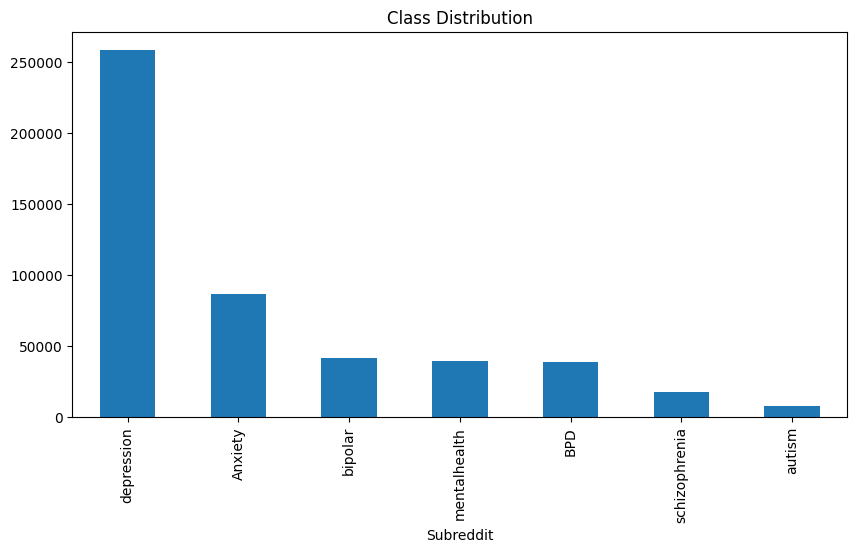

In [7]:
import matplotlib.pyplot as plt

df["Subreddit"].value_counts().plot(kind="bar", figsize=(10,5))
plt.title("Class Distribution")
plt.show()

<h3>Text Length Analysis</h3>

In [8]:
df["text_length"] = df["Text"].apply(lambda x: len(str(x).split()))

df["text_length"].describe()

,text_length
count,488472.000000
mean,190.101085
std,233.919334
min,0.000000
25%,61.000000
50%,123.000000
75%,235.000000
max,7798.000000


🚨 Key Observations
1️⃣ Highly Skewed Distribution

👉 Most posts are short-medium (50–300 words)

👉 Few extremely long posts → outliers

3️⃣ Long tail problem

👉 Posts with:  

1000+ words

7000+ words

❌ These add noise
❌ Increase TF-IDF sparsity
❌ Hurt Naive Bayes performance

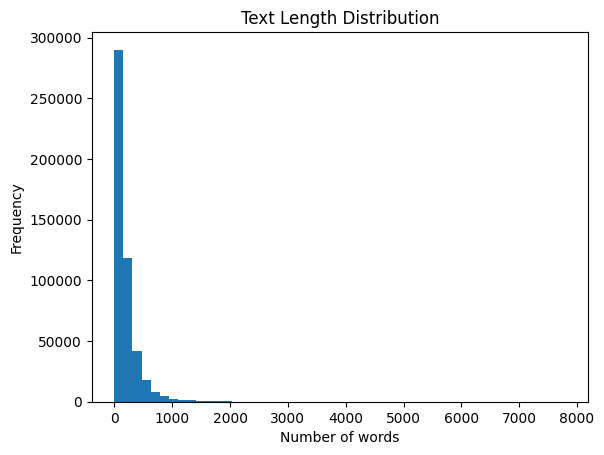

In [9]:
import matplotlib.pyplot as plt

plt.hist(df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

🎯 Decision (VERY IMPORTANT)

For Naive Bayes, we will:

✔️ Remove empty texts

✔️ Limit max text length (trim very long posts)

<h3>Removing the Posts with 0 words</h3>

In [10]:
df = df[df["text_length"] > 0]
print(df.shape)

(488387, 4)


<h3>Triming the long text</h3>

In [11]:
def trim_text(text, max_words=500):
    words = text.split()
    return " ".join(words[:max_words])

df["Text"] = df["Text"].apply(trim_text)
df.shape

(488387, 4)

<h3>Merge Title + Text</h3>

In [12]:
df["content"] = df["Title"] + " " + df["Text"]

<h3>Clean Text</h3>

In [13]:
import re

def clean_text(text):
    text = str(text).lower()  # Convert to string before applying lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["content"].apply(clean_text)

In [14]:
df["clean_text"]

,clean_text
0,exposure does not work i have struggled with s...
1,panic attack derealization cant go to doctors ...
2,how long can a panic attack last ive been with...
3,stepping stones first time poster long time lu...
4,coping with anxiety over climate change on the...
...,...
488467,religion and paranoid conversation ok ive got ...
488468,isnt this a little weird for being tardive dys...
488469,is this a symptom of schizophrenia or somethin...
488470,anyone seen the new black mirror episode bande...


<h3>Remove Stopwords</h3>

In [15]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in ENGLISH_STOP_WORDS])

df["clean_text"] = df["clean_text"].apply(remove_stopwords)

In [16]:
df["clean_text"].head()

,clean_text
0,exposure does work struggled social anxiety ch...
1,panic attack derealization doctors advice appr...
2,long panic attack ive withdrawing medicines la...
3,stepping stones time poster long time lurker i...
4,coping anxiety climate change verge considerin...


<h3>TF-IDF Feature Engineering</h3>

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,2),
    min_df=5,   # remove rare words
    max_df=0.9  # remove too common words
)

X = vectorizer.fit_transform(df["clean_text"])

In [18]:
X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34826609 stored elements and shape (488387, 15000)>

<h3>Label Encoding</h3>

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df["Subreddit"])

In [20]:
y

array([0, 0, 0, ..., 6, 6, 6])

<h3>Train-Test Split</h3>

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(X_train.shape, X_test.shape)

(390709, 15000) (97678, 15000)


In [23]:
from imblearn.over_sampling import SMOTE

# The error 'n_neighbors = 6, n_samples_fit = 2' indicates that
# SMOTE's default k_neighbors (which is 5, needing 6 samples including itself)
# is too high for a class with only 2 samples being processed internally.
# Setting k_neighbors to 1 will resolve this, allowing SMOTE to proceed.
# Note: k_neighbors=1 means synthetic samples are generated between a sample and its single nearest neighbor.
smote = SMOTE(k_neighbors=1, random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [38]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score, accuracy_score
import pandas as pd
import numpy as np

# Filter out NaN from class names before processing
class_names = [name for name in le.classes_ if pd.notna(name)]

results_f1 = []
results_acc = []

for i, class_name in enumerate(class_names):

    print(f"Processing: {class_name}")

    # Convert to binary (one-vs-rest)
    # Get the original index of the class name in le.classes_ for correct mapping
    original_idx = list(le.classes_).index(class_name)
    y_train_bin = (y_train== original_idx).astype(int)
    y_test_bin = (y_test == original_idx).astype(int)

    # Train model
    model = MultinomialNB(alpha=0.1)
    model.fit(X_train, y_train_bin)

    # Predict
    y_pred = model.predict(X_test)

    # F1 scores
    f1_pos = f1_score(y_test_bin, y_pred, pos_label=1)
    f1_neg = f1_score(y_test_bin, y_pred, pos_label=0)

    # Accuracy
    acc = accuracy_score(y_test_bin, y_pred)

    results_f1.append((class_name, f1_neg, f1_pos))
    results_acc.append((class_name, acc))

Processing: Anxiety
Processing: BPD
Processing: autism
Processing: bipolar
Processing: depression
Processing: mentalhealth
Processing: schizophrenia


In [39]:
f1_table = pd.DataFrame(results_f1, columns=["Class", "Non-Class F1", "Class F1"])
print(f1_table)

           Class  Non-Class F1  Class F1
0        Anxiety      0.937197  0.606860
1            BPD      0.966323  0.323583
2         autism      0.995215  0.550753
3        bipolar      0.964695  0.452741
4     depression      0.786812  0.823076
5   mentalhealth      0.958377  0.061475
6  schizophrenia      0.983870  0.280243


In [40]:
acc_table = pd.DataFrame(results_acc, columns=["Class", "Accuracy"])
print(acc_table)

           Class  Accuracy
0        Anxiety  0.891695
1            BPD  0.935840
2         autism  0.990530
3        bipolar  0.933670
4     depression  0.806630
5   mentalhealth  0.920289
6  schizophrenia  0.968447



🔹 Confusion Matrix for: Anxiety


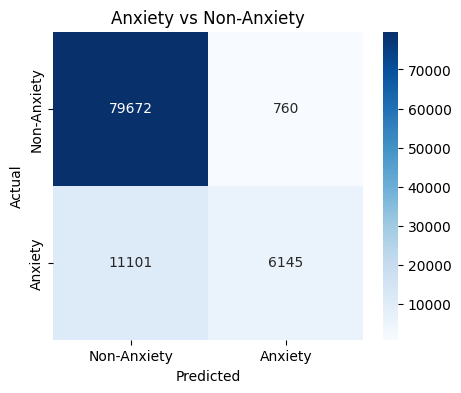


🔹 Confusion Matrix for: BPD


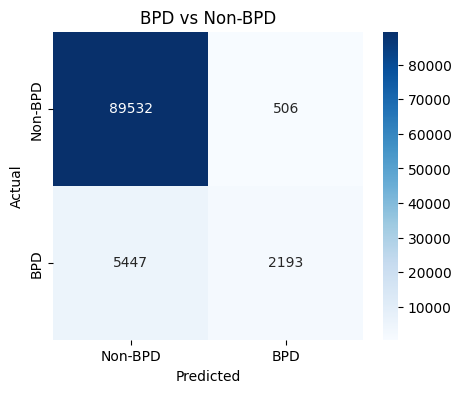


🔹 Confusion Matrix for: autism


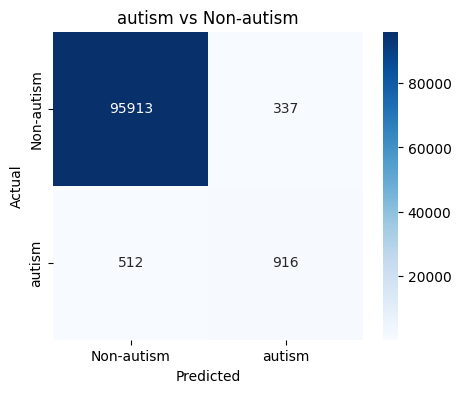


🔹 Confusion Matrix for: bipolar


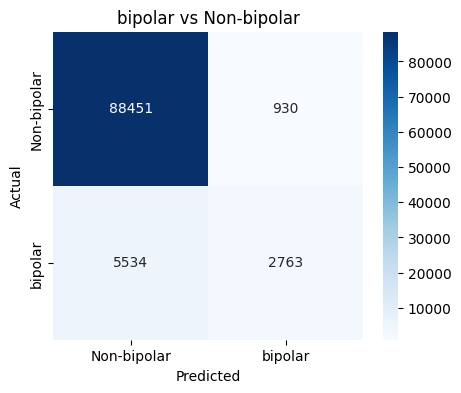


🔹 Confusion Matrix for: depression


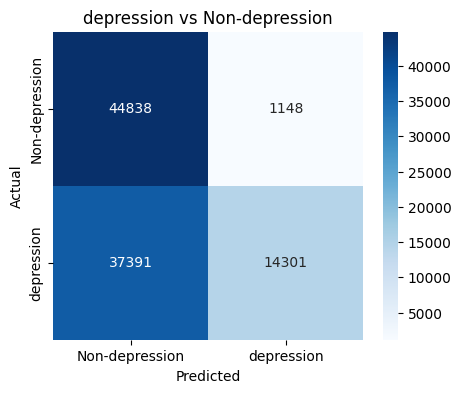


🔹 Confusion Matrix for: mentalhealth


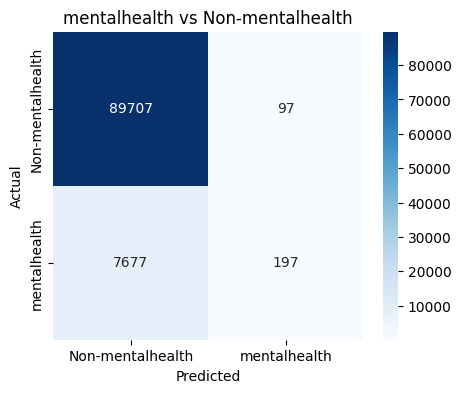


🔹 Confusion Matrix for: schizophrenia


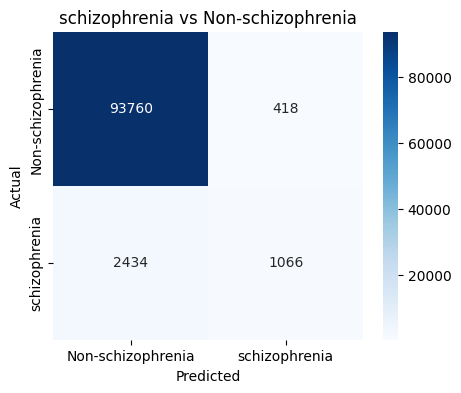

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

for i, class_name in enumerate(class_names):

    print(f"\n🔹 Confusion Matrix for: {class_name}")

    y_train_bin = (y_train_sm == i).astype(int)
    y_test_bin = (y_test == i).astype(int)

    model = MultinomialNB(alpha=0.1)
    model.fit(X_train_sm, y_train_bin)

    y_pred = model.predict(X_test)

    # Confusion Matrix
    cm = confusion_matrix(y_test_bin, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Non-" + class_name, class_name],
        yticklabels=["Non-" + class_name, class_name]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{class_name} vs Non-{class_name}")
    plt.show()

In [43]:
import joblib
joblib.dump(model, "naive_bayes_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [44]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import log_loss
import numpy as np

# Train a single multi-class Multinomial Naive Bayes model
# X_train, y_train, X_test, y_test are assumed to be defined from previous steps
model_multi = MultinomialNB(alpha=0.1) # Using the same alpha value as in previous examples
model_multi.fit(X_train, y_train)

# Get predicted probabilities for the test set
y_pred_proba = model_multi.predict_proba(X_test)

# Calculate the multi-class log loss
# log_loss expects true labels (y_test) and predicted probabilities
loss = log_loss(y_test, y_pred_proba)

print(f"Multi-class Log Loss for the Naive Bayes model: {loss:.4f}")

Multi-class Log Loss for the Naive Bayes model: 0.8697
